In [79]:
import pandas as pd

df = pd.read_csv('car.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [81]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [82]:
print(df['Fuel_Type'].unique())
print(df['Seller_Type'].unique())
print(df['Transmission'].unique())

['Petrol' 'Diesel' 'CNG']
['Dealer' 'Individual']
['Manual' 'Automatic']


In [83]:
df.replace({
    'Fuel_Type': {'Petrol': 0, 'Diesel': 1, 'CNG': 2},
    'Seller_Type': {'Dealer': 0, 'Individual': 1},
    'Transmission': {'Manual': 0, 'Automatic': 1}
}, inplace=True)

df.head()

/tmp/ipykernel_869/4211732674.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [84]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [85]:
df['Car_Age'] = 2026 - df['Year']

In [86]:
df[['Year', 'Car_Age']].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [87]:
df = df.drop(['Car_Name', 'Year'], axis=1)

In [88]:
df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,0,0,0,0,12
1,4.75,9.54,43000,1,0,0,0,13
2,7.25,9.85,6900,0,0,0,0,9
3,2.85,4.15,5200,0,0,0,0,15
4,4.60,6.87,42450,1,0,0,0,12


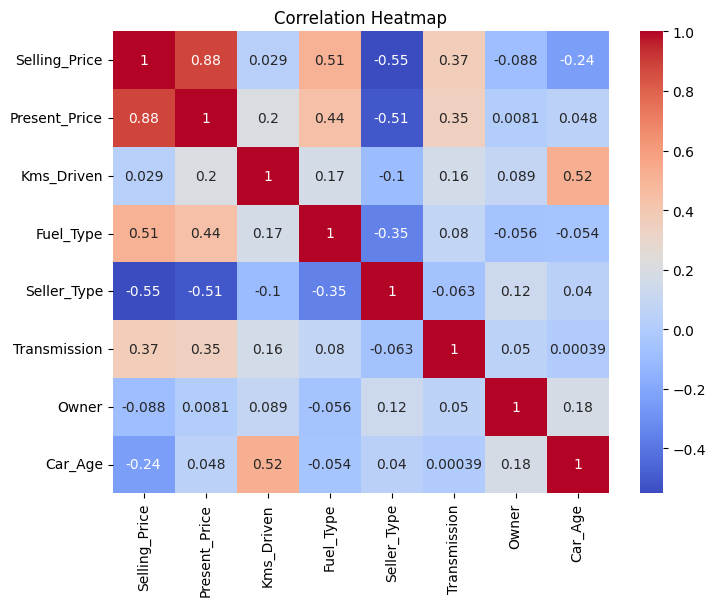

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [90]:
X = df.drop(['Selling_Price'], axis=1)
y = df['Selling_Price']

In [92]:
print(X.head())

   Present_Price  Kms_Driven  Fuel_Type  Seller_Type  Transmission  Owner  \
0           5.59       27000          0            0             0      0   
1           9.54       43000          1            0             0      0   
2           9.85        6900          0            0             0      0   
3           4.15        5200          0            0             0      0   
4           6.87       42450          1            0             0      0   

   Car_Age  
0       12  
1       13  
2        9  
3       15  
4       12  


In [93]:
print(y.head())

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


In [94]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [95]:
print(X_train.shape)
print(X_test.shape)

(240, 7)
(61, 7)


In [96]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [100]:
y_pred = model.predict(X_test)

In [101]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print("R2 Score:", score)

R2 Score: 0.9577568733252282


In [103]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
177,0.35,0.4263
289,10.11,10.5361
228,4.95,4.8400
198,0.15,0.2153
60,6.95,7.6125
9,7.45,6.4270
118,1.10,1.1007
154,0.50,0.5776
164,0.45,0.4666
33,6.00,6.7395


In [104]:
import pickle

pickle.dump(model, open('car_price_model.pkl', 'wb'))